# GLM analysis on the localizer data
It uses nilearn and performs the following steps:
1. Load the data from fmriPrep in BIDS format
2. Iterate on the subjects to:
   1. Select the predictors and confounds for the design matrix
   2. Generate 1st level model
   3. Estimate contrast maps
3. Generate group level maps
4. Generate hMT+ mask

In [5]:
# Imports
import os
import glob
from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.bids import save_glm_to_bids
from nilearn.glm import threshold_stats_img
from nilearn import plotting
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nilearn.glm.second_level import SecondLevelModel
from nilearn.reporting import get_clusters_table
from nilearn.image import math_img
from nilearn.masking import apply_mask

In [6]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep23/fmriprep"
task_label = "loc"
smoothing_fwhm = 6.0
high_pass_hz = 0.03

## 1. Load the data from fmriPrep in BIDS format

In [3]:
# import first level data automatically from fmriPrep derivatives
(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    hrf_model="spm",
    noise_model="ar2",
    smoothing_fwhm=smoothing_fwhm,
    high_pass=high_pass_hz,
    n_jobs=12,
    derivatives_folder=derivatives_folder,
)

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/first_level/first_level.py:1029: UserWarning: 'slice_time_ref' provided (0.0) is different from the value found in the BIDS dataset (0.455).
Note this may lead to the wrong model specification.
  warn(f"'slice_time_ref' provided ({slice_time_ref}) is different "


## 2. Iterate on the subjects

In [4]:
for idx,model in enumerate(models):
    print(f"Model {model}: {idx}")

    subject = f"sub-{model.subject_label}"

    # trim confounds
    confounds = models_confounds[idx][0][['csf','csf_derivative1','csf_power2','csf_derivative1_power2',
                                          'trans_x', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2',
                                          'trans_y', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2',
                                          'trans_z', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
                                          'rot_x', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2',
                                          'rot_y', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2',
                                          'rot_z', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2',
                                          ]]

    # replace NaNs with 0s in confounds
    confounds = confounds.fillna(0)
    
    # Fit and contrasts
    model.fit(models_run_imgs[idx], models_events[idx], confounds)

    z_map = model.compute_contrast("MovingPlaid - StaticPlaid", output_type="z_score")
    t_map = model.compute_contrast("MovingPlaid - StaticPlaid", output_type="stat")
    beta_map = model.compute_contrast("MovingPlaid - StaticPlaid", output_type="effect_size")

    # save maps to disk
    z_map.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm",
                                    f"{subject}_task-{task_label}_stat-z_con-MovingPlaidMinusStaticPlaid.nii.gz"))
    t_map.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm",
                                    f"{subject}_task-{task_label}_stat-t_con-MovingPlaidMinusStaticPlaid.nii.gz"))
    beta_map.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm",
                                    f"{subject}_task-{task_label}_stat-beta_con-MovingPlaidMinusStaticPlaid.nii.gz"))

    # create figure with thresholded map for fun
    clean_map, threshold = threshold_stats_img(
        z_map, alpha=0.05, height_control="bonferroni", cluster_threshold=50
    )

    plotting.plot_glass_brain(
        clean_map,
        colorbar=True,
        threshold=threshold,
        plot_abs=False,
        display_mode="ortho",
        figure=plt.figure(figsize=(10, 4)),
    )

    plt.savefig(os.path.join(
        data_dir,'derivatives','nilearn_glm',
        f"{subject}_task-{task_label}_plot-z_con-MovingPlaidMinusStaticPlaid_c-bonferroni_p-0.05_clusterk-50.png"
        )
    )

    # Export cluster table
    table = get_clusters_table(z_map, threshold, 50)
    table.to_csv(os.path.join(data_dir,"derivatives","nilearn_glm",
                              f"{subject}_task-{task_label}_table-clusters_con-MovingPlaidMinusStaticPlaid_c-bonferroni_p-0.05_clusterk-50.tsv"),sep='\t')
    

Model FirstLevelModel(high_pass=0.003, hrf_model='spm', n_jobs=12, noise_model='ar2',
                smoothing_fwhm=6.0, subject_label='07', t_r=1): 0


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/glm/_utils.py:319: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KeyboardInterrupt: 

## 3. Group level analysis

In [7]:
# List all tmap nii.gz files
tmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        'sub-*_task-loc_stat-t_con-MovingPlaidMinusStaticPlaid.nii.gz'
    )
)
tmap_files.sort()

# List all zmap nii.gz files
zmap_files = glob.glob(
    os.path.join(data_dir,'derivatives','nilearn_glm',
        'sub-*_task-loc_stat-z_con-MovingPlaidMinusStaticPlaid.nii.gz'
    )
)
zmap_files.sort()

subject_list = [os.path.basename(f).split('_')[0] for f in tmap_files]
subject_list

['sub-01',
 'sub-02',
 'sub-03',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-15',
 'sub-16',
 'sub-21',
 'sub-22',
 'sub-23']

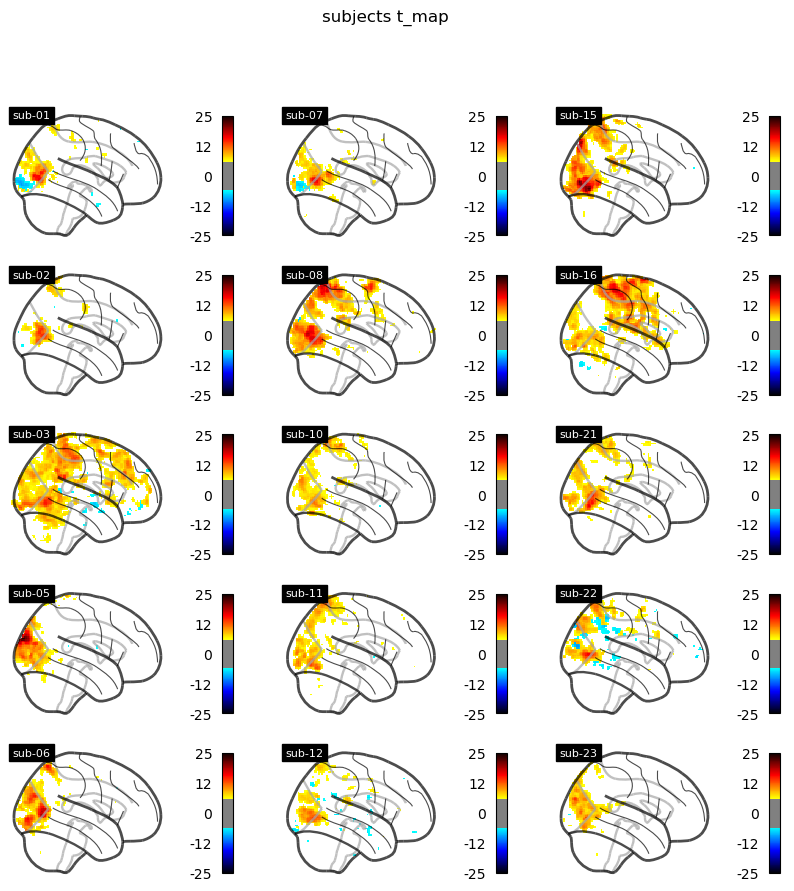

In [ ]:
#| label: loc_singlesubject
# Plot all subjects
#subjects = data["ext_vars"]["participant_id"].tolist()

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 10))
for cidx, tmap in enumerate(tmap_files):
    P = plotting.plot_glass_brain(
        tmap,
        colorbar=True,
        threshold=6.0,
        vmax=25,
        axes=axes[cidx % 5, int(cidx / 5)],
        plot_abs=False,
        display_mode="x",
    )
    P.title(subject_list[cidx], size=8)
fig.suptitle("subjects t_map")
plt.show()

In [8]:
# create design matrix for 2nd level
second_level_input = zmap_files
design_matrix_g = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

# define 2nd level model
second_level_model = SecondLevelModel(smoothing_fwhm=6.0, n_jobs=12)
second_level_model.minimize_memory = False
second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix_g,
)

# compute contrast (z score map)
z_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
)

# compute contrast (t score map)
t_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="stat",
)

# compute contrast (beta map)
beta_map_g = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type='effect_size',
)

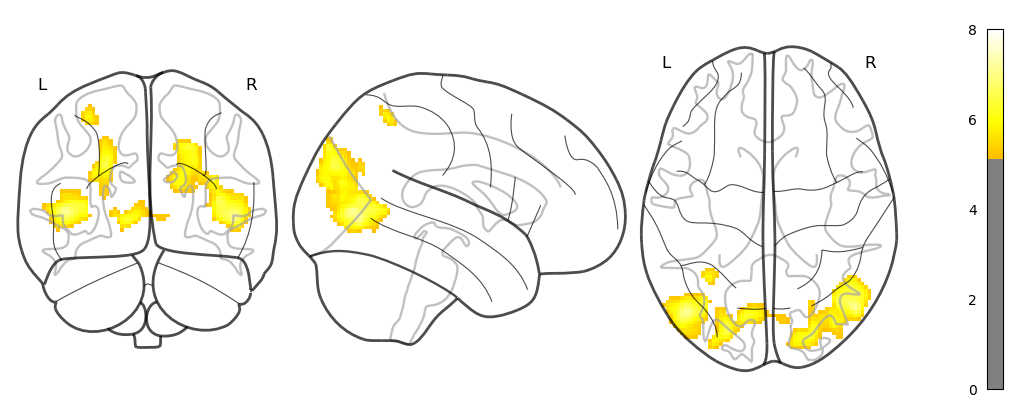

In [9]:
# Threshold zmap and plot it
clean_map_g, threshold_g = threshold_stats_img(
    z_map_g, alpha=0.05, height_control="bonferroni", cluster_threshold=50
)

plotting.plot_glass_brain(
    clean_map_g,
    colorbar=True,
    threshold=threshold_g,
    plot_abs=False,
    display_mode="ortho",
    vmax=8,
    figure=plt.figure(figsize=(10, 4)),
    symmetric_cbar=False,
    cmap=nilearn_cmaps["cold_hot"],
)

plt.savefig(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                         f"group_task-{task_label}_plot-z_con-MovingPlaidMinusStaticPlaid_c-bonferroni_p-0.05_clusterk-50.png"))

In [10]:
# Export cluster table
table,cluster_map_g = get_clusters_table(z_map_g, threshold_g+0.6, 50,
                                return_label_maps=True)

table.to_csv(os.path.join(data_dir,"derivatives","nilearn_glm","group",
                          f"group_task-{task_label}_table-clusters_con-MovingPlaidMinusStaticPlaid_c-bonferroni_p-0.05_clusterk-50.tsv"),sep='\t')
#print(table)
#print(table.to_latex())
table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,49.5,-72.5,1.5,7.178511,2728
1,1a,41.5,-68.5,9.5,6.638001,
2,1b,49.5,-64.5,5.5,6.537512,
3,2,-46.5,-74.5,3.5,7.164033,2024
4,3,-22.5,-84.5,31.5,6.512494,760
5,3a,-30.5,-90.5,25.5,5.908438,
6,4,23.5,-88.5,39.5,6.318916,728
7,4a,17.5,-90.5,21.5,6.066130,


In [28]:
# fetch X, Y, Z coordinates of the hMT lines of the table
hmt_coords = [(),()]
hmt_coords[0] = table[["X", "Y", "Z"]].iloc[0].tolist()
hmt_coords[1] = table[["X", "Y", "Z"]].iloc[3].tolist()
hmt_coords


[[49.5, -72.5, 1.5], [-46.5, -74.5, 3.5]]

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/matrix_plotting.py:366: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/interfaces/bids/glm.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  contrast_plot.figure.savefig(constrast_fig_file)


Extracting and saving residuals
Extracting and saving r_square


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  func(*args, **kwargs)


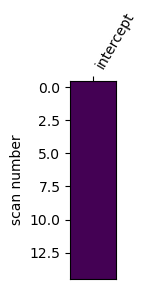

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


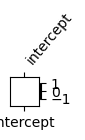

In [11]:
# Save z_map_g, t_map_g, beta_map_g
z_map_g.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",f"group_task-{task_label}_stat-z_con-MovingPlaidMinusStaticPlaid.nii.gz"))
t_map_g.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",f"group_task-{task_label}_stat-t_con-MovingPlaidMinusStaticPlaid.nii.gz"))
beta_map_g.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",f"group_task-{task_label}_stat-beta_con-MovingPlaidMinusStaticPlaid.nii.gz"))

In [ ]:
# View map interactively
plotting.view_img(clean_map_g,
         threshold=threshold_g
        )

# ROI analysis

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/js_plotting_utils.py:85: UserWarning: choosing both vmin and a threshold is not allowed; setting vmin to 0
  warnings.warn('choosing both vmin and a threshold is not allowed; '
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



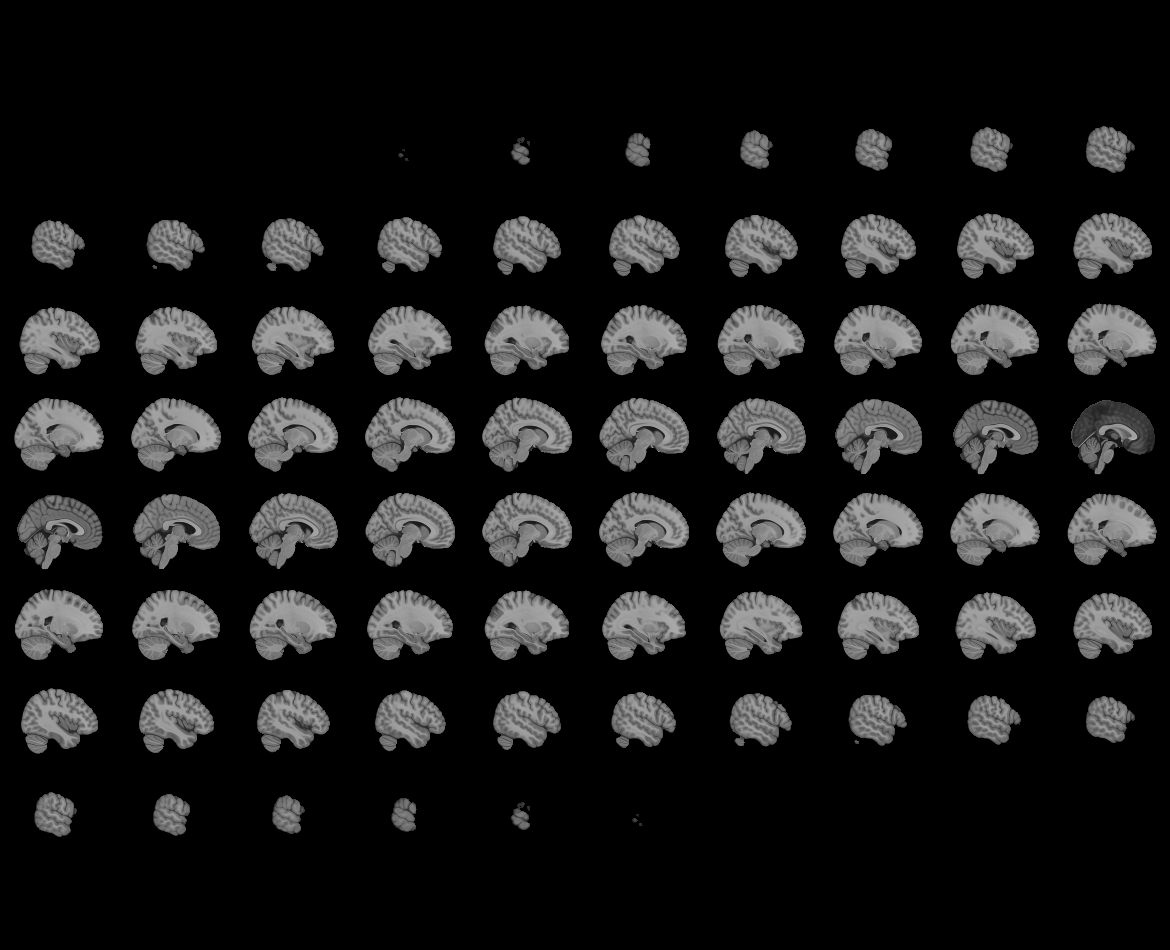
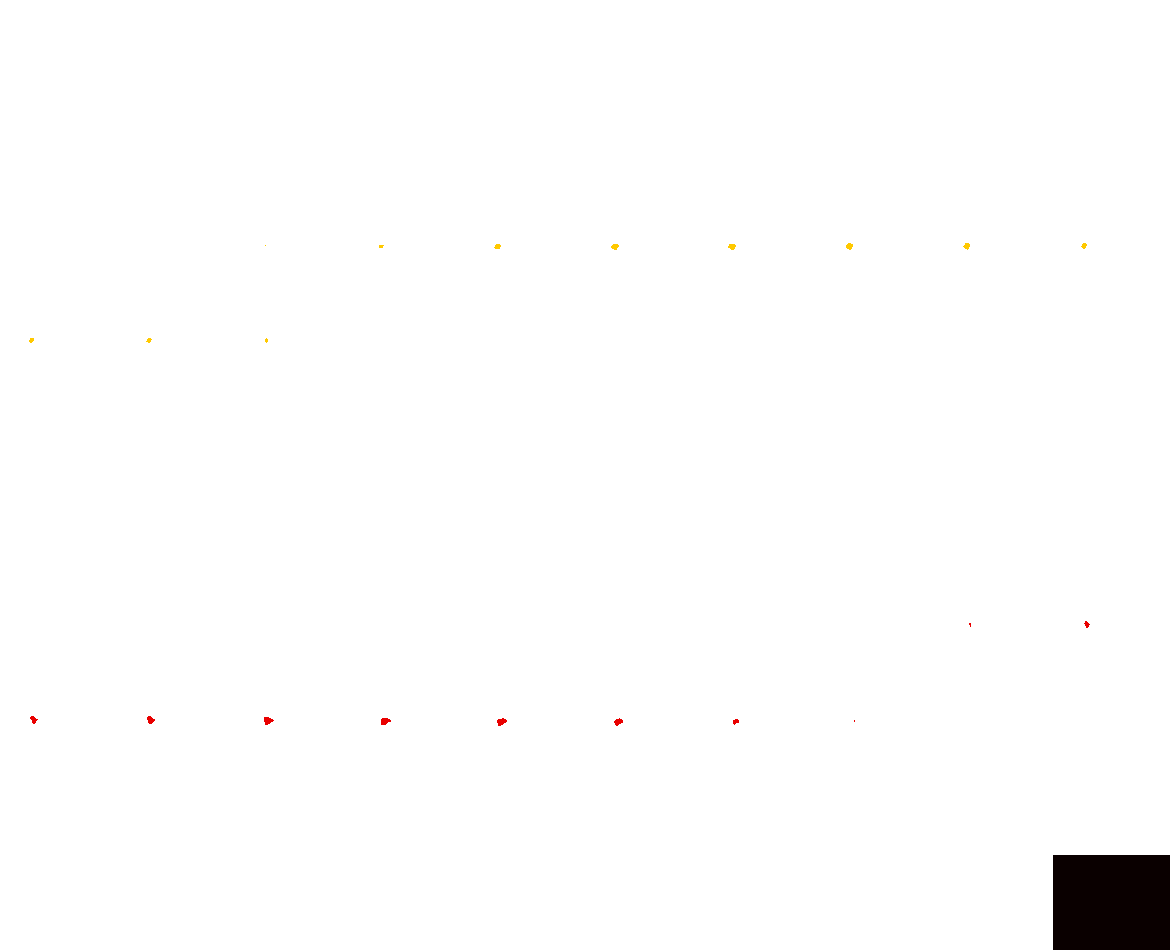

In [12]:
#| label: loc_group_interactive
# Show cluster_map_g
plotting.view_img(cluster_map_g[0],
                  vmax=3, vmin=0,
                  resampling_interpolation='nearest',
                  cmap='hot',
                  symmetric_cmap=False)

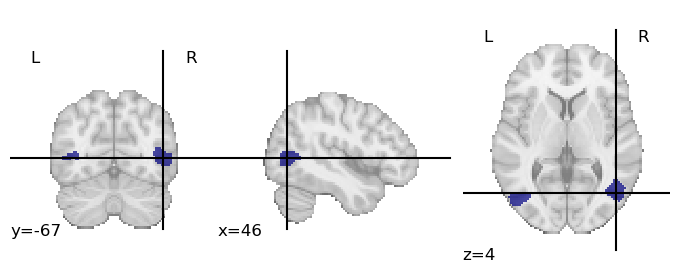

In [ ]:
# Generate bilateral hMT+ mask
# in this case, it is values 1 and 2 from cluster_map_g
aux_mask1 = math_img('img > 0', img=cluster_map_g[0])
aux_mask2 = math_img('img < 3', img=cluster_map_g[0])
mask_hMT = math_img('img1 * img2', img1=aux_mask1, img2=aux_mask2)

plotting.plot_roi(mask_hMT)

# save mask
mask_hMT.to_filename(os.path.join(data_dir,"derivatives","nilearn_glm","group",'mask_hMT.nii.gz'))


In [ ]:
# fetch map values inside mask_hMT  
# Apply mask to z_map_g
z_map_hMT = apply_mask(z_map_g, mask_hMT)

# Apply mask to beta_map_g
beta_map_hMT = apply_mask(beta_map_g, mask_hMT)

# Estimate mean of z_map_hMT
z_map_hMT_mean = np.mean(z_map_hMT)

z_map_hMT_mean

6.212508843783021